# Satellite-basemap classification maps — Viana do Castelo

Draws the Rock vs Seaweed classification (`Final_Classification.tif` produced by
`viana_de_castelo.ipynb`) over ESRI World Imagery, with the study-area boundary and
field/validation points.

**Outputs (figures/):**
* `Classification_Map_Basemap.png` — full map with legend
* `Classification_Map_Basemap_ZOOM.png` — zoom on the southern beds

Requires `contextily` and an internet connection (basemap tiles are downloaded).

In [1]:
# =============================================================================
# 0 · Imports & configuration
# =============================================================================
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---- File paths (point at the products generated by viana_de_castelo.ipynb) ----
BASE_DIR  = os.getcwd()   # run from the project folder
tif_path  = os.path.join(BASE_DIR, "figures/georeferenced_maps/Final_Classification.tif")
shp_path  = os.path.join(BASE_DIR, "data_used/pol_carreco_viana_2017.shp")
save_path = os.path.join(BASE_DIR, "figures/Classification_Map_Basemap.png")
zoom_path = os.path.join(BASE_DIR, "figures/Classification_Map_Basemap_ZOOM.png")

# ---- Specific points to overlay (lon, lat, EPSG:4326) ----
specific_points = [
    (-8.85032, 41.69445),
    (-8.85221, 41.69702),
    (-8.85393, 41.69721),
    (-8.86860, 41.72226),
    (-8.87752, 41.74032),
    (-8.87739, 41.74474),
    (-8.87752, 41.74032),
]
points_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([p[0] for p in specific_points],
                                [p[1] for p in specific_points]),
    crs="EPSG:4326")

# ---- Colour scheme (mentor-approved) ----
rock_color, seaweed_color = "#4682B4", "#FF4500"   # steel blue / orange red
TARGET_CRS = "EPSG:3857"                            # Web Mercator (needed by contextily)
ZOOM_BUFFER_M = 900                                 # padding around the southern beds
print("Configuration loaded.")

Configuration loaded.


In [2]:
# =============================================================================
# 1 · Load and inspect all data
# =============================================================================
print("=" * 70)
print("STEP 1: Inspecting coordinate systems...")

with rasterio.open(tif_path) as src:
    raster_data   = src.read(1)
    raster_crs    = src.crs
    raster_nodata = src.nodata
    raster_bounds = src.bounds
    src_transform = src.transform          # capture before the file closes

    print(f"Raster CRS   : {raster_crs}")
    print(f"Raster bounds: {raster_bounds}")
    print(f"Raster shape : {raster_data.shape}")
    print(f"Nodata value : {raster_nodata}")

valid_data     = raster_data[raster_data != raster_nodata]
rock_pixels    = int(np.sum(valid_data == 0))
seaweed_pixels = int(np.sum(valid_data == 1))
total_valid    = len(valid_data)
print(f"Rock (0)   : {rock_pixels:,} px ({rock_pixels/total_valid*100:.1f}%)")
print(f"Seaweed (1): {seaweed_pixels:,} px ({seaweed_pixels/total_valid*100:.1f}%)")

shapefile = gpd.read_file(shp_path)
print(f"Shapefile CRS   : {shapefile.crs}")
print(f"Shapefile bounds: {shapefile.total_bounds}")

STEP 1: Inspecting coordinate systems...
Raster CRS   : EPSG:4326
Raster bounds: BoundingBox(left=-8.88074489880559, bottom=41.67374434558872, right=-8.844273298270338, top=41.74929266098317)
Raster shape : (841, 406)
Nodata value : -9999.0
Rock (0)   : 23,496 px (97.3%)
Seaweed (1): 640 px (2.7%)
Shapefile CRS   : EPSG:3763
Shapefile bounds: [-60918.39342768 224893.22584361 -59584.39101581 227671.47257692]


In [3]:
# =============================================================================
# 2 · Unify everything to Web Mercator (EPSG:3857)
# =============================================================================
print("\nSTEP 2: Converting all data to Web Mercator...")

transform, width, height = calculate_default_transform(
    raster_crs, TARGET_CRS, raster_data.shape[1], raster_data.shape[0], *raster_bounds)

# Initialise the destination with nodata and pass src/dst nodata so that pixels
# outside the swath stay transparent (not filled with 0 = Rock).
reprojected_raster = np.full((height, width), raster_nodata, dtype=raster_data.dtype)
reproject(
    source=raster_data, destination=reprojected_raster,
    src_transform=src_transform, src_crs=raster_crs,
    dst_transform=transform, dst_crs=TARGET_CRS,
    src_nodata=raster_nodata, dst_nodata=raster_nodata,
    resampling=Resampling.nearest,
)

reprojected_bounds = (
    transform[2],
    transform[5] + transform[4] * height,
    transform[2] + transform[0] * width,
    transform[5],
)
print(f"Reprojected bounds: {reprojected_bounds}")
print(f"New shape         : {reprojected_raster.shape}")

shapefile_web = shapefile.to_crs(TARGET_CRS) if shapefile.crs != TARGET_CRS else shapefile
points_web    = points_gdf.to_crs(TARGET_CRS)
print(f"{len(specific_points)} points converted to Web Mercator")


STEP 2: Converting all data to Web Mercator...
Reprojected bounds: (-988600.0, 5112226.903742771, -984535.0919816273, 5123498.367932517)
New shape         : (879, 317)
7 points converted to Web Mercator


In [4]:
# =============================================================================
# 3 · Binary colormap + masked display raster
# =============================================================================
cmap = ListedColormap([rock_color, seaweed_color])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)   # <0.5 -> rock, >=0.5 -> seaweed

if raster_nodata is not None:
    display_raster = np.ma.masked_equal(reprojected_raster, raster_nodata)
    print(f"Nodata pixels masked: {int(display_raster.mask.sum())}")
else:
    display_raster = reprojected_raster

extent = [reprojected_bounds[0], reprojected_bounds[2],
          reprojected_bounds[1], reprojected_bounds[3]]

Nodata pixels masked: 258969


## Full map — `Classification_Map_Basemap.png`

Basemap added.


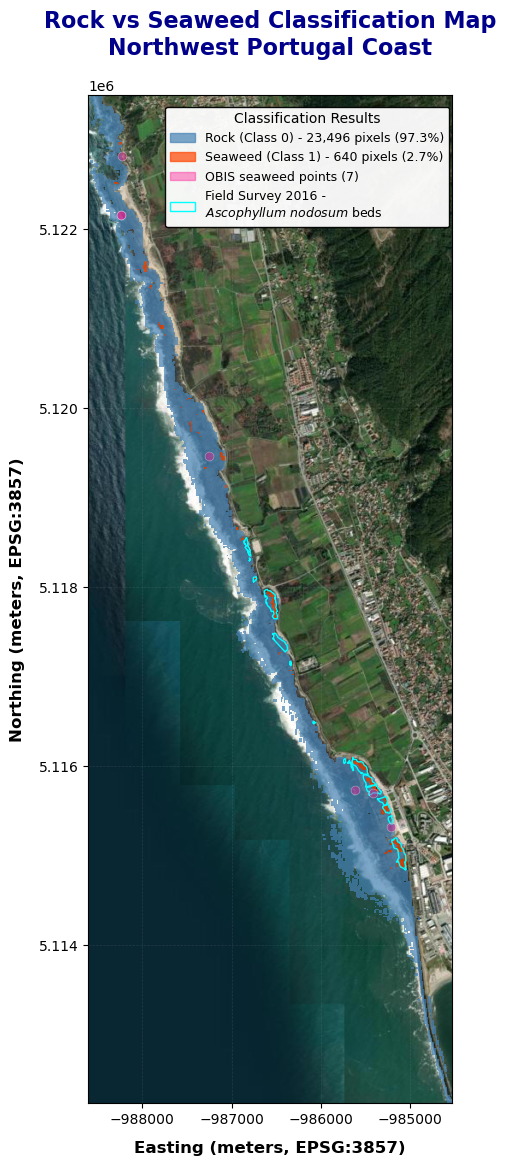


Saved: /Users/priyankashukla/Documents/BioEcoOcean/viana_de_castelo/figures/Classification_Map_Basemap.png
Map width ~4.1 km | Rock 97.3% | Seaweed 2.7%


In [5]:
# =============================================================================
# 4 · Full classification map over ESRI imagery
# =============================================================================
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(reprojected_bounds[0], reprojected_bounds[2])
ax.set_ylim(reprojected_bounds[1], reprojected_bounds[3])

# ---- basemap ----
try:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.Esri.WorldImagery,
                    zoom=14, attribution=False)
    print("Basemap added.")
except Exception as e:
    print(f"Basemap error: {e}; trying OpenStreetMap...")
    try:
        ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.OpenStreetMap.Mapnik, zoom=14)
    except Exception:
        print("Could not add any basemap.")

# ---- classification raster ----
ax.imshow(display_raster, extent=extent, cmap=cmap, norm=norm, alpha=0.7,
          origin="upper", zorder=2, interpolation="nearest")

# ---- validation points (small, transparent) ----
ax.scatter(points_web.geometry.x, points_web.geometry.y, c="#FF1493", s=40,
           marker="o", edgecolor="white", linewidth=0.5, alpha=0.4, zorder=4)

# ---- study-area boundary (cyan) ----
shapefile_web.boundary.plot(ax=ax, edgecolor="cyan", linewidth=1.0, zorder=3)

# ---- title, axes ----
ax.set_title("Rock vs Seaweed Classification Map\nNorthwest Portugal Coast",
             fontsize=16, fontweight="bold", pad=15, color="darkblue", y=1.02)
ax.set_xlabel("Easting (meters, EPSG:3857)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Northing (meters, EPSG:3857)", fontsize=12, fontweight="bold", labelpad=10)
ax.tick_params(axis="both", which="major", labelsize=10)

# ---- legend ----
legend_patches = [
    mpatches.Patch(color=rock_color, alpha=0.7,
                   label=f"Rock (Class 0) - {rock_pixels:,} pixels ({rock_pixels/total_valid*100:.1f}%)"),
    mpatches.Patch(color=seaweed_color, alpha=0.7,
                   label=f"Seaweed (Class 1) - {seaweed_pixels:,} pixels ({seaweed_pixels/total_valid*100:.1f}%)"),
    mpatches.Patch(color="#FF1493", alpha=0.4,
                   label=f"OBIS seaweed points ({len(specific_points)})"),
    mpatches.Patch(color="cyan", alpha=1.0, fill=False, linewidth=1.0,
                   label="Field Survey 2016 -\n$\\it{Ascophyllum\\ nodosum}$ beds"),
]
legend = ax.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.01, 0.995),
                   ncol=1, fontsize=9, title="Classification Results", title_fontsize=10,
                   fancybox=True, framealpha=0.95, edgecolor="black")
legend.set_zorder(100)

ax.grid(True, alpha=0.15, linestyle="--", linewidth=0.5, zorder=1)
fig.subplots_adjust(top=0.92, bottom=0.08, left=0.08, right=0.95)
fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()

map_width_m = reprojected_bounds[2] - reprojected_bounds[0]
print(f"\nSaved: {save_path}")
print(f"Map width ~{map_width_m/1000:.1f} km | Rock {rock_pixels/total_valid*100:.1f}% | "
      f"Seaweed {seaweed_pixels/total_valid*100:.1f}%")

## Zoom map — `Classification_Map_Basemap_ZOOM.png`

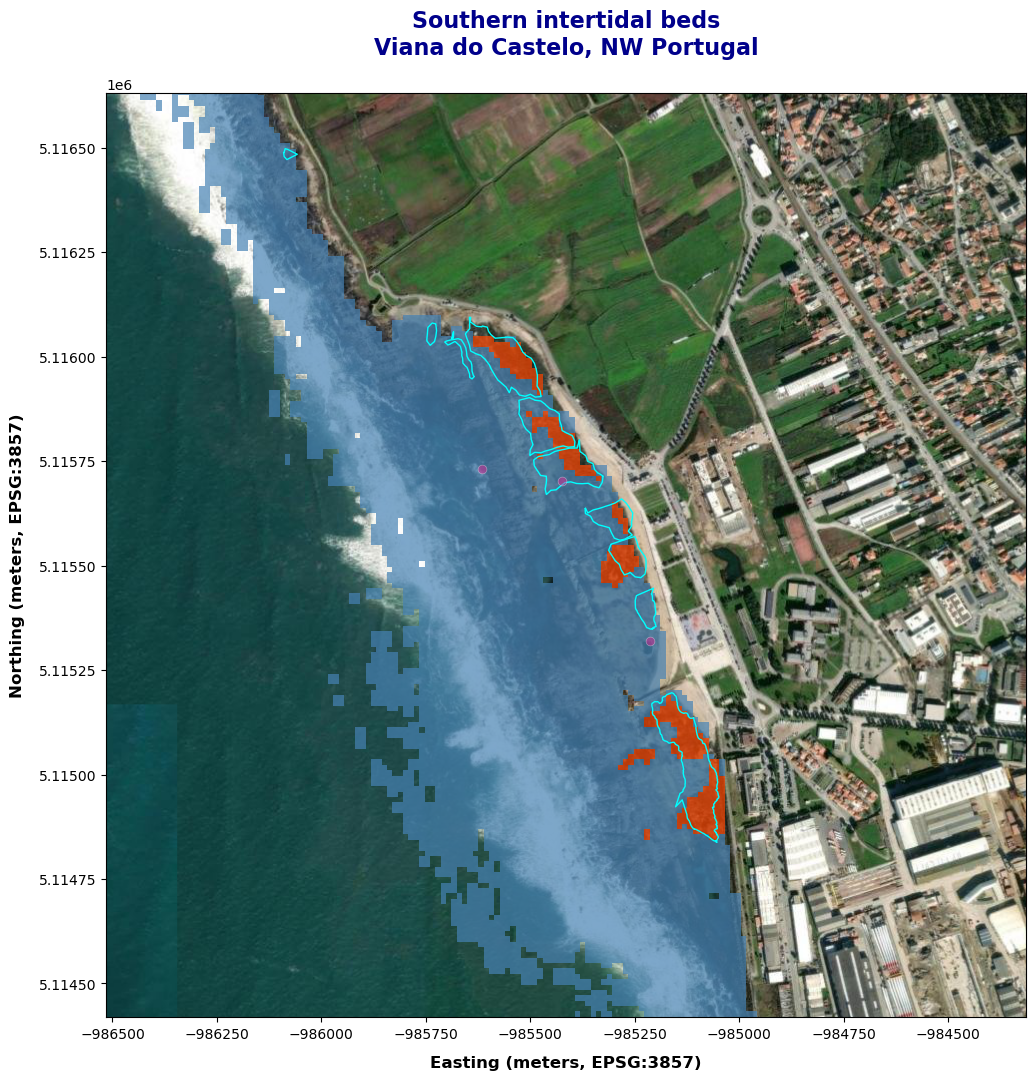

Saved: /Users/priyankashukla/Documents/BioEcoOcean/viana_de_castelo/figures/Classification_Map_Basemap_ZOOM.png


In [6]:
# =============================================================================
# 5 · Zoom on the southern intertidal beds (no legend, sharper tiles)
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_xlim(reprojected_bounds[0], reprojected_bounds[2])
ax.set_ylim(reprojected_bounds[1], reprojected_bounds[3])

try:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.Esri.WorldImagery,
                    zoom=14, attribution=False)
except Exception as e:
    print(f"Basemap error: {e}")

ax.imshow(display_raster, extent=extent, cmap=cmap, norm=norm, alpha=0.7,
          origin="upper", zorder=2, interpolation="nearest")
ax.scatter(points_web.geometry.x, points_web.geometry.y, c="#FF1493", s=40,
           marker="o", edgecolor="white", linewidth=0.5, alpha=0.4, zorder=4)
shapefile_web.boundary.plot(ax=ax, edgecolor="cyan", linewidth=1.0, zorder=3)

ax.set_title("Southern intertidal beds\nViana do Castelo, NW Portugal",
             fontsize=16, fontweight="bold", pad=15, color="darkblue", y=1.02)
ax.set_xlabel("Easting (meters, EPSG:3857)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Northing (meters, EPSG:3857)", fontsize=12, fontweight="bold", labelpad=10)

# frame = 3 southernmost points, buffered
south_idx = np.argsort([lat for _lon, lat in specific_points])[:3]
sx0, sy0, sx1, sy1 = points_web.iloc[south_idx].total_bounds
ax.set_xlim(sx0 - ZOOM_BUFFER_M, sx1 + ZOOM_BUFFER_M)
ax.set_ylim(sy0 - ZOOM_BUFFER_M, sy1 + ZOOM_BUFFER_M)

# sharper tiles for the smaller window (above old basemap, below the raster)
try:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.Esri.WorldImagery,
                    zoom=16, attribution=False, zorder=1.5)
except Exception as e:
    print(f"Kept existing tiles ({e})")

fig.savefig(zoom_path, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved: {zoom_path}")